# Example Classifier Walkthrough

Adapted from Google Keras code example [Image classification from scratch](https://keras.io/examples/vision/image_classification_from_scratch/)

 - Load libraries
 - Getting the data
 - Preprocessing
    - Standard image size
    - Splitting to train/test
 - Train a CNN and evaluate the results
 - Try the model on a new data source

 ## Remember first
 1. Activate a virtual environment `conda env` or `source .venv/bin/activate`
 2. `pip install -r requirements.txt` 

In [1]:
# Install required packages
%pip install -q numpy matplotlib tensorflow

# If apple silicon install tensorflow-metal
import os

if os.uname().machine == "arm64":
    %pip install -q tensorflow-macos tensorflow-metal
    pass

%reset -f


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
import os

# import pydot # NOTE: need graphviz installed in the system
import hashlib
import shutil
import random
import glob
import pickle

# Create folders if they don't exist
%mkdir -p models
%mkdir -p checkpoints

# Constants
REBUILD = False
IMAGE_SIZE = (180, 180)
BATCH_SIZE = 128
NUM_CLASSES = 3
ZIP_HASH = "eedec42a8a363b8ff299a0f2d6eedadafc3af3e7"
MODEL_PATH = "models/animals.keras"
HISTORY_PATH = MODEL_PATH + ".history.pkl"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = (
    "3"  # 2 for most warnings, 3 to suppress all warnings
)

# Get the image datasets

All image datasets will be stored in the `3-image_classification/animals` folder

## Option 1 - download zip from data.badmath.org

This is enabled in the next cell, you do not have to do it manually.

1. Download zip from data.badmath.org
2. Unzip folder
3. Delete zip file


## Option 2 - manual download from kaggle

This will take some downloading, unzipping, and moving/renaming files and folders.

### "Cat and Dog"
1. Download the dataset from https://www.kaggle.com/datasets/tongpython/cat-and-dog
2. Move the zip into the `animals` folder
3. Unzip it, I've called the folder `animals/cat_and_dog`
4. Move the images to remove to duplicate nested folders `test_set/test_set` and `training_set/training_set` folders -> `test_set` and `training_set`
5. Add an empty folder `pandas` next to `cats` and `dogs` in `training_set`
6. You should have images such as `animals/cat_and_dog/test_set/cats/cat.4001.jpg`

### "Animal Image Dataset"
1. Download the dataset from https://www.kaggle.com/datasets/ashishsaxena2209/animal-image-datasetdog-cat-and-panda
2. Move the zip into the `animals` folder
3. Unzip it, I've called the folder `animals/animal_images`
4. Remove folders for unused labels leaving `cats`, `dogs`, and `pandas`
5. You should have images such as `animals/animal_images/cats/cats_00001.jpg`


In [ ]:
# Download image datasets

# Skip this if you've already got a directory called 'animals' (e.g. if you've run this before)
if not os.path.exists("animals"):
    # Use curl to download the zip if it's not already there
    if not os.path.exists("animals.zip"):
        !curl -L -o animals.zip 'https://data.badmath.org/animals.zip'

    hash = hashlib.sha1(open("animals.zip", "rb").read()).hexdigest()
    if hash == ZIP_HASH:
        print("✅ Download hash validated")
    else:
        raise Exception("❌ ERROR: Download hash does not match!")

    # Unzip the downloaded file into `animals`
    os.mkdir("animals")
    shutil.unpack_archive("animals.zip", "animals")

    os.remove("animals.zip")

In [ ]:
# Check for corrupted images
train = "animals/cat_and_dog/training_set/"
valid = "animals/cat_and_dog/test_set/"
world = "animals/animal_images/"

num_skipped = 0
for data_dir in (train, valid, world):
    for animal in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, animal)
        if os.path.isdir(folder_path):
            for fname in os.listdir(folder_path):
                fpath = os.path.join(folder_path, fname)
                if not os.path.isfile(fpath):
                    continue  # Skip directories
                try:
                    with open(fpath, "rb") as fobj:
                        is_jfif = tf.compat.as_bytes("JFIF") in fobj.peek(10)
                except Exception as e:
                    print(f"Error reading {fpath}: {e}")
                    is_jfif = False
                if not is_jfif:
                    num_skipped += 1
                    print("Deleted %s" % fpath)
                    # Delete corrupted image
                    os.remove(fpath)

print("Deleted %d images" % num_skipped)


Deleted 0 images


Found 8005 files belonging to 3 classes.
Found 2023 files belonging to 3 classes.
Found 3000 files belonging to 3 classes.


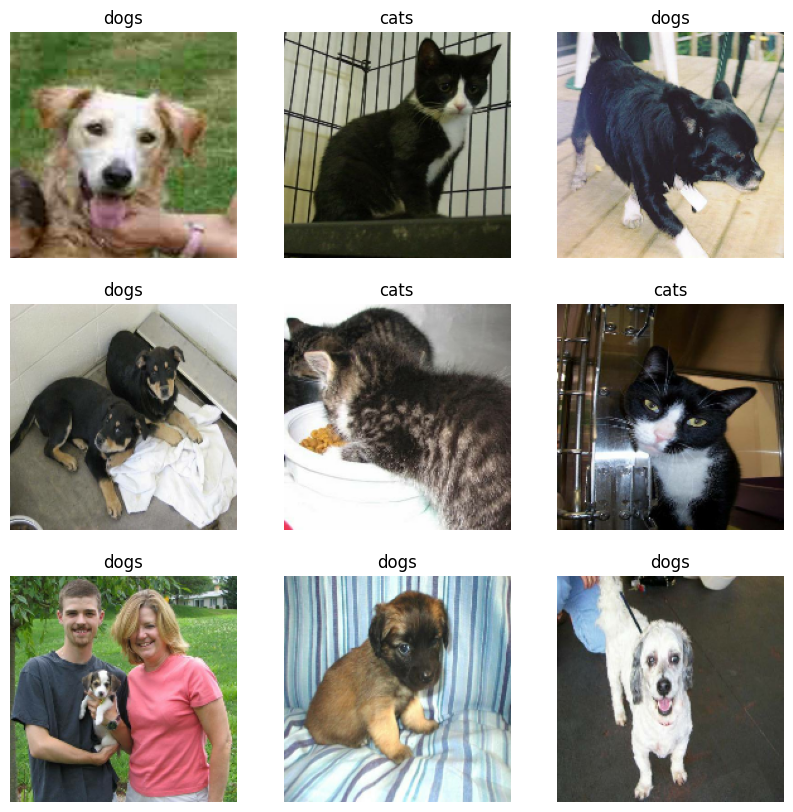

In [ ]:
# Set the class names
class_names = os.listdir(train)

train_ds = tf.keras.utils.image_dataset_from_directory(
    train,
    labels="inferred",
    subset=None,
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)
train_classes = train_ds.class_names
train_ds = train_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid,
    labels="inferred",
    subset=None,
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)
valid_classes = valid_ds.class_names
valid_ds = valid_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))


world_ds = tf.keras.utils.image_dataset_from_directory(
    world,
    labels="inferred",
    subset=None,
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)
world_classes = world_ds.class_names
world_ds = world_ds.map(lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)))

# Show 3 images from each class in the training set
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_classes[tf.argmax(labels[i])])
        plt.axis("off")


In [6]:
# Find the minimum and maximum dimensions of images in the training set
min_height = 9999
min_width = 9999

for images, labels in train_ds:
    for image in images:
        height, width, _ = image.shape
        if height < min_height:
            min_height = height
        if width < min_width:
            min_width = width

print("Minimum training dimensions:", min_height, "x", min_width)

# Find the minimum and maximum dimensions of images in the validation set
min_height = 9999
min_width = 9999

for images, labels in valid_ds:
    for image in images:
        height, width, _ = image.shape
        if height < min_height:
            min_height = height
        if width < min_width:
            min_width = width

print("Minimum validation dimensions:", min_height, "x", min_width)

Minimum training dimensions: 180 x 180
Minimum validation dimensions: 180 x 180


# Build a model

This code defines a convolutional neural network (CNN) using the Keras library. The network architecture consists of multiple blocks of separable convolutional layers, with residual connections between the blocks. The last layer is a dense layer with either sigmoid or softmax activation, depending on the number of classes. The model is created by calling the make_model function with the input shape and number of classes as arguments, and the resulting model is plotted using keras.utils.plot_model.

This is a simplified version of the Xception architecture (https://arxiv.org/abs/1610.02357).

Here is a quick description of the *layers* in our neural network:
 - `keras.Input(shape=input_shape)` creates an input layer with the specified input shape.
 - `layers.Rescaling(1.0 / 255)` rescales the input values by dividing them by 255.
 - `layers.Conv2D(128, 3, strides=2, padding="same")` creates a 2D convolutional layer with 128 filters, a kernel size of 3x3, a stride of 2, and same padding.
 - `layers.BatchNormalization()` normalizes the outputs of the previous layer to speed up training and reduce overfitting.
 - `layers.Activation("relu")` applies the ReLU activation function to the previous layer's outputs.
 - `layers.SeparableConv2D(size, 3, padding="same")` creates a depthwise separable convolutional layer with size filters, a kernel size of 3x3, and same padding.
 - `layers.MaxPooling2D(3, strides=2, padding="same")` applies max pooling to the previous layer's outputs, reducing their size by a factor of 2.
 - `layers.Conv2D(size, 1, strides=2, padding="same")` creates a 2D convolutional layer with size filters, a kernel size of 1x1, a stride of 2, and same padding.
 - `layers.add([x, residual])` adds the outputs of the previous layer and the residual layer.
 - `layers.GlobalAveragePooling2D()` calculates the average of each feature map in the previous layer's outputs.
 - `layers.Dropout(0.5)` randomly drops out 50% of the previous layer's outputs during training to reduce overfitting.
 - `layers.Dense(units, activation=activation)` creates a fully connected layer with units output nodes and the specified activation function.


In [ ]:
# Define a model
# This is a simplified version of the Xception architecture (https://arxiv.org/abs/1610.02357).


def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    # Entry block
    x = layers.Rescaling(1.0 / 255)(inputs)
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512, 728]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(size, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        activation = "sigmoid"
        units = 1
    else:
        activation = "softmax"
        units = num_classes

    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(units, activation=activation)(x)
    return keras.Model(inputs, outputs)


In [ ]:
# Train the model

epochs = 25

if REBUILD:
    model = make_model(input_shape=IMAGE_SIZE + (3,), num_classes=NUM_CLASSES)

    # Uncomment to show model summary plot
    # keras.utils.plot_model(model, show_shapes=True)

    # Callbacks are functions that are called at specific points during training
    # They can be used to save models, stop training early, adjust learning rates, etc.
    callbacks = [
        # ModelCheckpoint saves the model after each epoch
        # This creates files like "checkpoints/save_at_1.keras", "checkpoints/save_at_2.keras", etc.
        # Useful for:
        # 1. Resuming training if it gets interrupted
        # 2. Keeping a history of model weights throughout training
        # 3. Analyzing how model weights change over time
        keras.callbacks.ModelCheckpoint("checkpoints/save_at_{epoch}.keras"),
        # Other common callbacks (not used here) include:
        # - EarlyStopping: Stops training when a metric stops improving
        # - ReduceLROnPlateau: Reduces learning rate when a metric plateaus
        # - TensorBoard: Logs metrics for visualization
    ]
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        # loss="binary_crossentropy",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        train_ds,
        epochs=epochs,
        callbacks=callbacks,
        validation_data=valid_ds,
    )
    history_data = history.history

    # Save the model and history
    model.save(MODEL_PATH)
    with open(HISTORY_PATH, "wb") as file:
        pickle.dump(history_data, file)
else:
    if not os.path.exists(MODEL_PATH):
        !curl -L -o {MODEL_PATH} 'https://data.badmath.org/animals.keras'
    if not os.path.exists(HISTORY_PATH):
        !curl -L -o {HISTORY_PATH} 'https://data.badmath.org/animals.keras.history.pkl'
    # Load the saved model and history
    model = keras.models.load_model(MODEL_PATH)
    with open(HISTORY_PATH, "rb") as file:
        history_data = pickle.load(file)


/Users/christopher/Documents/datasci_223/.venv/lib/python3.12/site-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


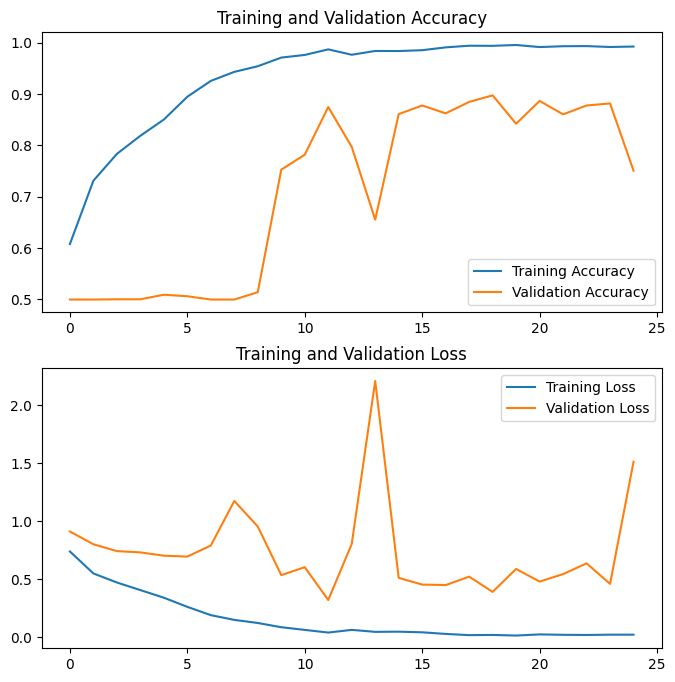

16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 676ms/step - accuracy: 0.7554 - loss: 1.4492
Validation loss: 1.51
Validation accuracy: 0.75


In [ ]:
# Now with 100% more plotting!
# Plot the learning curves
acc = history_data["accuracy"]
val_acc = history_data["val_accuracy"]
loss = history_data["loss"]
val_loss = history_data["val_loss"]

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(2, 1, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

# Evaluate the model
val_loss, val_accuracy = model.evaluate(valid_ds)
print(f"Validation loss: {val_loss:.2f}")
print(f"Validation accuracy: {val_accuracy:.2f}")


In [10]:
# Evaluate on the (cat, dog, panda) dataset
world_ds = world_ds.prefetch(buffer_size=32)
model.evaluate(world_ds)

24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 675ms/step - accuracy: 0.5130 - loss: 7.7483


[7.782843589782715, 0.5106666684150696]

In [ ]:
# Run inference on a new image
img = keras.preprocessing.image.load_img(
    world + "pandas/panda_00016.jpg", target_size=IMAGE_SIZE
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
class_index = tf.argmax(predictions, axis=1)[0]
score = float(predictions[0][class_index])

print(
    f"This image is a {world_classes[class_index]} with a probability of {100 * score:.2f}%."
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
This image is a dogs with a probability of 100.00%.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


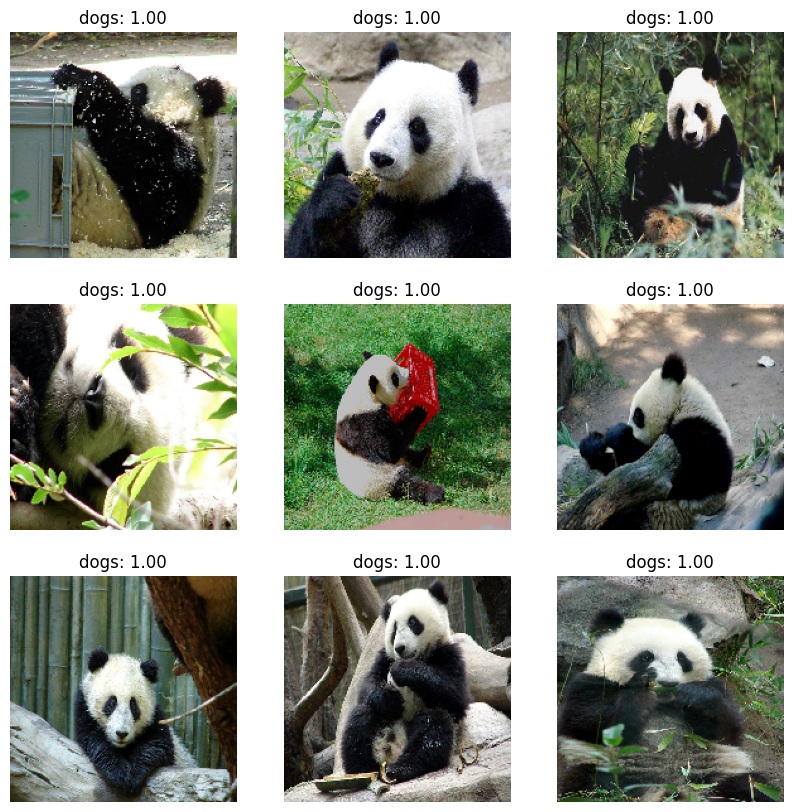

In [ ]:
# How well does the model perform on the (cat, dog, panda) dataset? Especially on the pandas?!?

# Get list of all panda image file paths
panda_paths = glob.glob(world + "pandas/*.jpg")

# Randomly select 9 panda images
sample_panda_paths = random.sample(panda_paths, 9)

# Create subplot for each image
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

# Loop through each image and its corresponding subplot
for i, path in enumerate(sample_panda_paths):
    img = keras.preprocessing.image.load_img(path, target_size=IMAGE_SIZE)
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch axis
    predictions = model.predict(img_array)
    score = predictions[0]
    class_index = score.argmax()
    class_name = world_classes[class_index]
    prob = score[class_index]
    axs[i // 3][i % 3].imshow(img_array[0] / 255.0)
    axs[i // 3][i % 3].set_title(f"{class_name}: {prob:.2f}")
    axs[i // 3][i % 3].axis("off")

plt.show()